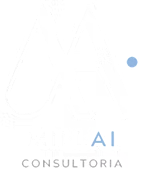

# Klike Data Science Challenge - Millai

**Autor:** Carlos Vitor Freitas Santos  

---

## Contexto de Negócio

A Millai é uma consultoria especializada na intersecção entre Marketing e Inteligência Artificial. Seu principal produto, o **Klike**, é uma plataforma inovadora que utiliza IA para analisar anúncios em vídeo. O Klike pontua os criativos, identifica oportunidades de melhoria e apoia os times de marketing na tomada de decisões estratégicas.

Neste projeto, trabalharemos com um dataset contendo 500 registros de campanhas de vídeo veiculadas em diferentes plataformas (como Meta, TikTok e LinkedIn). O objetivo principal é entender e prever o **Klike Score** (`klike_score`), uma pontuação de 0 a 100 gerada pela IA que representa a qualidade geral de um criativo.

## Objetivos da Análise

Este notebook foi estruturado para resolver o desafio técnico seguindo um pipeline lógico de Ciência de Dados, focado em pragmatismo e geração de valor:

1. **Análise Exploratória de Dados (EDA):** Investigar o comportamento das métricas, distribuições e identificar quais características do vídeo (como duração, formato e presença de rosto humano) mais se correlacionam com um alto desempenho.
2. **Modelagem Preditiva:** Construir e avaliar um modelo capaz de prever o `klike_score` com base nos atributos do criativo.
3. **Motor de Recomendações (Insights):** Traduzir os resultados do modelo em recomendações acionáveis, quantificadas e contextualizadas para otimizar futuras campanhas.

---

## Dicionário de Dados

Abaixo estão os detalhes de cada atributo presente no dataset simulado, abrangendo características do criativo e métricas de performance:

| Coluna | Descrição |
| :--- | :--- |
| `campaign_id` | Identificador único da campanha |
| `date` | Data de veiculação |
| `platform` | Plataforma (Meta, Tik Tok, LinkedIn) |
| `category` | Categoria do anunciante (E-commerce, SaaS, App Install, Branding, Lead Gen) |
| `objective` | Objetivo da campanha (awareness, traffic, conversions, engagement, app_install) |
| `target_audience_age`| Faixa etária do público-alvo (18-24, 25-34, 35-44, 45+) |
| `is_retargeting` | Se a campanha é de retargeting (True) ou prospecção (False) |
| `video_duration_s` | Duração do vídeo em segundos |
| `format` | Formato do vídeo (vertical, horizontal, quadrado) |
| `has_subtitle` | Se o vídeo possui legendas |
| `has_cta` | Se o vídeo possui call-to-action |
| `has_hook` | Se o vídeo possui hook nos primeiros 3 segundos |
| `has_face` | Se o vídeo apresenta rosto humano |
| `text_density` | Quantidade de texto on-screen (low, medium, high) |
| `music_voice_ratio` | Proporção música/voz (0 = só voz, 1 = só música) |
| `impressions` | Número de impressões |
| `clicks` | Número de cliques |
| `ctr` | Click-through rate |
| `cpc` | Custo por clique (R$) |
| `spend` | Gasto total (R$) |
| `conversions` | Número de conversões |
| `revenue` | Receita gerada (R$) |
| `roas` | Return on Ad Spend |
| `avg_watch_time_s` | Tempo médio de visualização do vídeo (segundos) |
| `engagement_rate` | Taxa de engajamento (likes + comentários + compartilhamentos / impressões) |
| **`klike_score`** | **Score de qualidade do criativo (0-100) — Variável Target** |

---

## *1. Importação de bibliotecas e configuração do ambiente*

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/klike_challenge_dataset.csv")

df.head()

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,...,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,NaN,vertical,True,...,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,...,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
2,KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,...,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1
3,KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,...,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9
4,KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,...,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9
